# Implement folder Planck equation
Test version

In [1]:
import numpy as np
import torch
from scipy.integrate import solve_bvp
import matplotlib.pyplot as plt
import os, warnings
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
warnings.filterwarnings("ignore", category=UserWarning,
                        message="KMP_DUPLICATE_LIB_OK")


In [2]:
p_sil=0.75# 10-3 mutation rate times nb of amino acids=250 so total is 0.25 mutation per cycle
p_let=0.05*(1-p_sil)
p_aa=0.95*(1-p_sil)
mu_M=-0.13*np.log(10)
sigma_M=0.37*np.log(10)
S_mat=None                      # shape (N_h, n_A) : s_{k,v} ∈ {±1}

E_a=3.4                        # Ag-gate threshold
kBT=1                       # thermal factor
N_i=2000  
N_max=2000 
mu_i=0.0 
sigma_i=0.1
p_diff=0.10


    # ---------------- mutation statistics -------------------------------
f_aa  = p_aa / (p_aa + p_sil)
f_sil = 1.0 - f_aa
v_adv = f_aa * mu_M
D     = f_aa * (sigma_M**2 + f_sil * mu_M**2)
lam = np.log(2.0) + np.log1p(-p_let) + np.log1p(-p_diff)

In [3]:


# ---------------------------------------------------------------------
# 1.  Run FP simulation  +  build Γ & ∇Γ lists
# ---------------------------------------------------------------------
def fp_density_time_series_kD(
    # biological / model parameters ---------------------------------------

    get_C=lambda t, v: 5.0,          # user-supplied concentration C_v(t)
    S_mat=None,                      # shape (N_h, n_A) : s_{k,v} ∈ {±1}
    N_i=N_i,  N_max=N_max,
    # grid / time ----------------------------------------------------------
    h_min=-3.0, h_max=10.0, d_h=0.1,
    T=30.0,  dt=0.01,
    # output ---------------------------------------------------------------
    snapshot_interval=0.005,
    verbose=False,
):
    """
    Simulate k-dimensional GC Fokker–Planck dynamics in h-space.

    Parameters
    ----------
    S_mat : ndarray (N_h, n_A)
        Binary motif matrix: each column = antigen, each row = shape component.
    get_C : callable (t, v) → C_v(t)
        Returns surface concentration of antigen v at time t.
    """
    # ---------------- basic checks --------------------------------------
    if S_mat is None:
        raise ValueError("S_mat (binary motif matrix) must be provided")
    N_h, n_A = S_mat.shape          # k = dimension of h



    if D > 0.0:
        dt_max = d_h**2 / (2.0 * N_h * D)
        if dt > dt_max:
            raise ValueError(f"dt = {dt:.3g} exceeds CFL limit {dt_max:.3g}")


    # ---------------- k-dim Cartesian grid ------------------------------
    h_axis = np.arange(h_min, h_max + d_h, d_h)
    h_axes = (h_axis,) * N_h
    h_mesh = np.meshgrid(*h_axes, indexing="ij")      # list of length k
    dH     = d_h**N_h

    # ---------------- Gaussian initial population -----------------------
    g1d = np.exp(-(h_axis - mu_i) ** 2 / (2.0 * sigma_i**2))
    rho = np.prod(np.meshgrid(*([g1d] * N_h), indexing="ij"), axis=0)
    rho *= N_i / (rho.sum() * dH)

    snapshots = [rho.copy()]
    times     = [0.0]

    # ---------------- pre-allocate helper arrays ------------------------
    E_stack = np.zeros((n_A,) + rho.shape)           # energies  E_v(h)

    n_steps    = int(round(T / dt))
    snap_every = max(1, int(round(snapshot_interval / dt)))
    omegas=[0]
    # -------------------------------------------------------------------
    for step in range(1, n_steps + 1):
        t_now = step * dt
        N_pop = rho.sum() * dH

        # --- time-dependent concentrations -----------------------------
        C_vec  = np.array([get_C(t_now, v) for v in range(n_A)], dtype=float)
        C_tot  = C_vec.sum()

        # If no antigen is present, skip selection (pure drift/diffusion)
        if C_tot == 0.0:
            if verbose and step % snap_every == 0:
                print(f"{step:5d}  t={t_now:6.2f}  (no antigen present)")
            if step % snap_every == 0:
                snapshots.append(rho.copy());  times.append(t_now)
            continue

        # --- binding energies  E_v(h) ----------------------------------
        # S_mat.T : (n_A, N_h);  stacked h_mesh : (N_h, …grid…)
        E_stack = np.tensordot(S_mat.T, np.stack(h_mesh, axis=0), axes=(1, 0))
        #            → shape (n_A, …grid…)

        # Broadcast C_v to all grid points
        C_broad = C_vec.reshape((n_A,) + (1,) * N_h)

        # --- antigen internalisation gate  P_Ag ------------------------
        exp_term  = np.exp((E_stack - E_a) / kBT)
        numer_PAg = (C_broad * exp_term).sum(axis=0)
        P_Ag      = numer_PAg / (1.0 + numer_PAg)

        # --- T‐cell help gate  P_T  (concentration-weighted) ----------
        eE   = np.exp(E_stack / kBT)
        Phi  =  eE.sum(axis=0)                 # Σ_v C_v e^{E_v/kBT}
        Phi_bar = (rho * Phi).sum() * dH / N_pop
        P_T  = Phi / (Phi + Phi_bar / C_tot)

        # --- growth/decay rate Γ(h,t) ----------------------------------
        log_sel = np.log(P_Ag) + np.log(P_T)
        avg_log = (rho * log_sel).sum() * dH / N_pop
        Omega   = 0.0 if N_pop < N_max+0.1 else max(0.0, lam + avg_log)
        Gamma   = lam + log_sel - Omega

        # --- conservative flux divergence ------------------------------
        div_total = np.zeros_like(rho)
        for ax in range(N_h):
            rho_fwd  = np.roll(rho, -1, axis=ax)

            adv_flux  = v_adv * (rho if v_adv >= 0 else rho_fwd)
            diff_flux = -0.5 * D * (rho_fwd - rho) / d_h
            J_int     = adv_flux + diff_flux            # at cell interfaces

            # trim last cell (fwd neighbour outside domain)
            slc = [slice(None)] * N_h;  slc[ax] = slice(0, -1)
            J_int = J_int[tuple(slc)]

            # build full flux array with zero at boundaries
            J_shape = list(rho.shape); J_shape[ax] += 1
            J = np.zeros(J_shape)
            idx = [slice(None)] * N_h;  idx[ax] = slice(1, -1)
            J[tuple(idx)] = J_int

            div_total += np.diff(J, axis=ax) / d_h

        # --- explicit Euler update -------------------------------------
        rho += dt * (Gamma * rho - div_total)
        np.maximum(rho, 0.0, out=rho)                    # clip negatives

        # --- book-keeping ----------------------------------------------
        if step % snap_every == 0:
            snapshots.append(rho.copy())
            times.append(t_now)
            omegas.append(Omega)

        if verbose and step % snap_every == 0:
            mean_Gamma = (rho * Gamma).sum() * dH / N_pop
            mean_h = [(rho * h_mesh[ax]).sum() * dH / N_pop for ax in range(N_h)]
            mean_h_str = "  ".join(f"⟨h_{i+1}⟩={m:6.2f}" for i, m in enumerate(mean_h))
            print(f"{step:5d}  t={t_now:6.2f}  N={N_pop:8.1f}  Ω={Omega:7.3f}  "
                  f"⟨Γ⟩={mean_Gamma:8.3f}  {mean_h_str}")

    return h_axes, np.array(times), np.stack(snapshots), np.array(omegas)



In [4]:
def run_fp(S_mat, get_C, *, T=20.0, verbose=False):
    """
    Returns a dict 'fp_ctx' with everything downstream functions need.
    """
    axes, times, rho_t, omegas = fp_density_time_series_kD(
        S_mat=S_mat, get_C=get_C, T=T, verbose=verbose
    )

    # ---------- Φ̄(t_k) --------------------------------------------
    N_h, n_A  = S_mat.shape
    d_h       = axes[0][1] - axes[0][0]
    dH        = d_h**N_h
    h_mesh    = np.meshgrid(*axes, indexing="ij")
    E_full    = np.tensordot(S_mat.T, np.stack(h_mesh, axis=0), axes=(1, 0))

    Phi_bar = np.zeros_like(times, dtype=float)
    for k, t_now in enumerate(times):
        C_vec = np.array([get_C(float(t_now), v) for v in range(n_A)])
        Phi   = ( np.exp(E_full/kBT)).sum(axis=0)
        rho   = rho_t[k]
        Phi_bar[k] = (rho * Phi).sum()*dH / (rho.sum()*dH)

    # ---------- Γ & ∇Γ snapshots (autograd) ------------------------
    S_torch = torch.tensor(S_mat, dtype=torch.float64)
    gamma_list, grad_list = [], []

    for k, t_now in enumerate(times):
        Phi_b  = float(Phi_bar[k])
     
        omega  = float(omegas[k])
        C_vec  = np.array([get_C(float(t_now), v) for v in range(n_A)], dtype=float)
        C_t    = torch.tensor(C_vec, dtype=torch.float64)

        def γ(h_t, C_t=C_t, Phi_b=Phi_b, omega=omega):
            E_v  = torch.mv(S_torch.T, h_t)
            P_Ag = (C_t * torch.exp((E_v - E_a) / kBT)).sum()
            P_Ag = P_Ag / (1.0 + P_Ag)
            Phi  = torch.exp(E_v / kBT).sum()
            P_T  = Phi / (Phi + Phi_b / C_t.sum())
            return lam + torch.log(P_Ag) + torch.log(P_T) - omega

        def gγ_np(h_np, γ=γ):          # capture γ itself
            h_t = torch.tensor(h_np, requires_grad=True, dtype=torch.float64)
            γ(h_t).backward()
            return h_t.grad.numpy()

        gamma_list.append(γ)
        grad_list.append(gγ_np)

    return dict(
        axes=axes, times=times, rho_t=rho_t, omegas=omegas,
        Phi_bar=Phi_bar,
        gamma_list=gamma_list, grad_list=grad_list,
        S_mat=S_mat, get_C=get_C
    )



In [5]:
import numpy as np
import matplotlib.pyplot as plt

def plot_fp_density_time_dim(fp_ctx, dim=0, *,
                             disp_step=5, cmap="viridis",
                             sol=None, t_clip=5.0):
    """
    Heat-map of ρ(t, h_dim), with colour-bar max taken from times ≥ t_clip.

    Parameters
    ----------
    fp_ctx   : dict   – output of run_fp
    dim      : int    – which h-coordinate to show (0-based)
    disp_step: float  – x-tick spacing
    cmap     : str    – Matplotlib colormap
    sol      : BVPResult or None – optional trajectory overlay
    t_clip   : float  – ignore times < t_clip when computing vmax
    """
    axes, times, rho_t = fp_ctx["axes"], fp_ctx["times"], fp_ctx["rho_t"]
    N_h = len(axes)
    if not (0 <= dim < N_h):
        raise ValueError(f"dim must be in [0,{N_h-1}]")

    h_axis = axes[dim]

    # --- marginal over all dims except `dim` --------------------------
    marginal_axes = tuple(i + 1 for i in range(N_h) if i != dim)  # +1 for time
    dH = np.prod([(axes[i][1] - axes[i][0]) for i in range(N_h)
                  if i != dim]) if N_h > 1 else 1.0
    rho_marg = rho_t.sum(axis=marginal_axes) * dH                 # (n_t, n_h)

    # --- choose vmax from t ≥ t_clip ----------------------------------
    idx_start = np.searchsorted(times, t_clip)          # first t ≥ t_clip
    vmax_clip = rho_marg[idx_start:].max()

    # --- plot ----------------------------------------------------------
    plt.figure(figsize=(8, 5))
    im = plt.imshow(rho_marg.T, origin="lower", aspect="auto",
                    extent=[times[0], times[-1], h_axis[0], h_axis[-1]],
                    cmap=cmap, vmin=0.0, vmax=vmax_clip)

    plt.colorbar(im, label=rf"$\rho(t,h_{{{dim+1}}})$")
    plt.xlabel("Time", fontsize=14)
    plt.ylabel(rf"$h_{{{dim+1}}}$", fontsize=14)
    plt.title(rf"Density $\rho(t,h_{{{dim+1}}})$ ")

    plt.xticks(np.arange(times[0], times[-1] + 1e-9, disp_step))

    if sol is not None:
        plt.plot(sol.x, sol.y[dim], color="red", lw=1.4,
                 label=rf"least-action $h_{{{dim+1}}}(t)$")
        plt.legend()

    plt.tight_layout()
    plt.show()





In [6]:
def make_grad_Gamma(fp_ctx):
    times, grads = fp_ctx["times"], fp_ctx["grad_list"]
    def grad(h, t):
        if t <= times[0]:  return grads[0](h)
        if t >= times[-1]: return grads[-1](h)
        hi = np.searchsorted(times, t)
        lo = hi - 1
        w  = (t-times[lo])/(times[hi]-times[lo])
        return (1.-w)*grads[lo](h) + w*grads[hi](h)
    return grad
from scipy.integrate import solve_bvp

def solve_optimal_trajectory(
        hf, fp_ctx, *, mesh=300, max_nodes=20_000, plot=False):
    """
    Computes the least-action trajectory from h(t0)=0 to h(tf)=hf.
    Works for arbitrary dimensionality N = fp_ctx["S_mat"].shape[0].
    """
    # ---------------- basic info ----------------
    times   = fp_ctx["times"]
    grad_G  = make_grad_Gamma(fp_ctx)
    t0, tf  = times[0], times[-1]
    N       = fp_ctx["S_mat"].shape[0]          # number of h coordinates

    # ------------- final boundary vector -------------
    if np.isscalar(hf):
        hf = np.repeat(float(hf), N)            # same target for every dim
    else:
        hf = np.asarray(hf, dtype=float)
        if hf.size != N:
            raise ValueError(
                f"hf must have length {N} (one per shape dim); got {hf.size}")

    # ----------------- ODE system --------------------
    # state y = (h, v)  ⇒  size 2N
    def ode(t, y):
        h, v = y[:N], y[N:]                      # each is shape (N, len(t))
        a    = np.empty_like(h)
        for j, tj in enumerate(t):               # loop over mesh points
            a[:, j] = -D * grad_G(h[:, j], tj)   # acceleration
        return np.vstack((v, a))

    # ------------- boundary conditions --------------
    def bc(ya, yb):
        # ya[:N]  : h(t0)  ;  yb[:N] : h(tf)
        return np.hstack((ya[:N], yb[:N] - hf))

    # ------------- initial mesh & guess -------------
    t_mesh  = np.linspace(t0, tf, mesh)
    y_guess = np.zeros((2 * N, mesh))
    for i in range(N):                           # linear interpolation guess
        y_guess[i] = hf[i] * (t_mesh - t0) / (tf - t0)

    # ------------- solve BVP ------------------------
    sol = solve_bvp(ode, bc, t_mesh, y_guess, max_nodes=max_nodes)
    if not sol.success:
        raise RuntimeError(sol.message)

    # ------------- optional plot --------------------
    if plot:
        plt.figure(figsize=(6, 3))
        for i in range(N):
            plt.plot(sol.x, sol.y[i], label=rf"$h_{i+1}$")
        plt.xlabel("time")
        plt.ylabel("shape coordinate")
        plt.legend()
        plt.tight_layout()
        plt.show()

    return sol


def compute_least_action(sol, fp_ctx, *, baseline=True, verbose=False):
    """
    Return S_opt   (and S_lin when baseline=True)
    Compatible with any number N = S_mat.shape[0] of shape coordinates.
    """
    # ------------------------------------------------------------------
    times   = fp_ctx["times"]
    omegas  = fp_ctx["omegas"]
    Phi_bar = fp_ctx["Phi_bar"]
    get_C   = fp_ctx["get_C"]
    S_mat   = fp_ctx["S_mat"]
    n_A     = S_mat.shape[1]
    N       = S_mat.shape[0]               # number of h coordinates

    # constants (assumed already defined in the notebook)
    v_vec   = f_aa * mu_M * np.ones(N)     # deterministic drift term

    # --- torch version of S_mat for Γ --------------------------------
    S_T     = torch.tensor(S_mat, dtype=torch.float64)

    # -------------------- Γ(t, h) ------------------------------------
    def Γ(t, h_np):
        """
        Growth rate minus omega at time t and shape h (numpy array length N).
        Returns a scalar float.
        """
        # match given t to nearest entry in 'times'
        k      = int(np.argmin(np.abs(times - t)))
        omega  = omegas[k]
        Phi_b  = Phi_bar[k]

        C_vec  = np.array([get_C(float(times[k]), v) for v in range(n_A)],
                          dtype=float)

        # torch variables
        h_t = torch.tensor(h_np, dtype=torch.float64)
        C_t = torch.tensor(C_vec, dtype=torch.float64)

        # energy of each antigen
        E_v = torch.mv(S_T.T, h_t)         # shape (n_A,)

        # binding probability to target antigen
        PAg = (C_t * torch.exp((E_v - E_a) / kBT)).sum()
        PAg = PAg / (1.0 + PAg)

        # total binding probability (any antigen)
        Phi = (torch.exp(E_v / kBT)).sum()
        PT  = Phi / (Phi + Phi_b / C_t.sum())

        return (lam + torch.log(PAg) + torch.log(PT) - omega).item()

    # ----------------- extract optimal traj ---------------------------
    t_mesh = sol.x                       # shape (m,)
    h_opt  = sol.y[:N].T                 # shape (m, N)
    v_opt  = sol.y[N:2*N].T              # shape (m, N)

    # ----------------- action functional ------------------------------
    def S_of(h, v):
        g    = np.array([Γ(ti, hi) for ti, hi in zip(t_mesh, h)])
        kin  = np.sum((v - v_vec) ** 2, axis=1) / (2 * D)
        return -np.trapz(g - kin, t_mesh)

    S_opt = S_of(h_opt, v_opt)
    if not baseline:
        if verbose:
            print(f"S_opt = {S_opt:.6e}")
        return S_opt

    # ---------------- linear baseline trajectory ----------------------
    slope  = h_opt[-1] / (t_mesh[-1] - t_mesh[0])      # vector length N
    h_lin  = (t_mesh[:, None] - t_mesh[0]) * slope[None, :]
    v_lin  = np.tile(slope, (len(t_mesh), 1))
    S_lin  = S_of(h_lin, v_lin)

    if verbose:
        print(f"S_opt = {S_opt:.6e}   S_lin = {S_lin:.6e}   ΔS = {S_lin - S_opt:.6e}")

    return S_opt, S_lin



Running FP simulation for T=30 seconds
Optimal trajectory: (300,) with shape (2, 300)


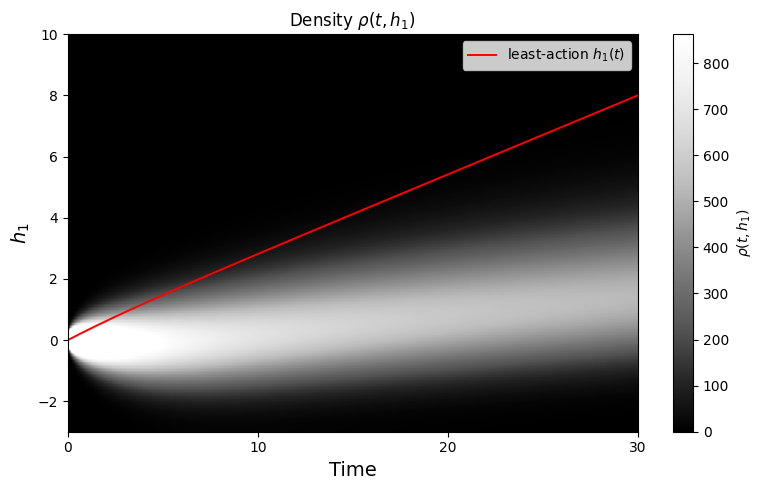

S_opt = 5.952495e+00   S_lin = 5.969967e+00   ΔS = 1.747164e-02

Running FP simulation for T=100 seconds
Optimal trajectory: (300,) with shape (2, 300)


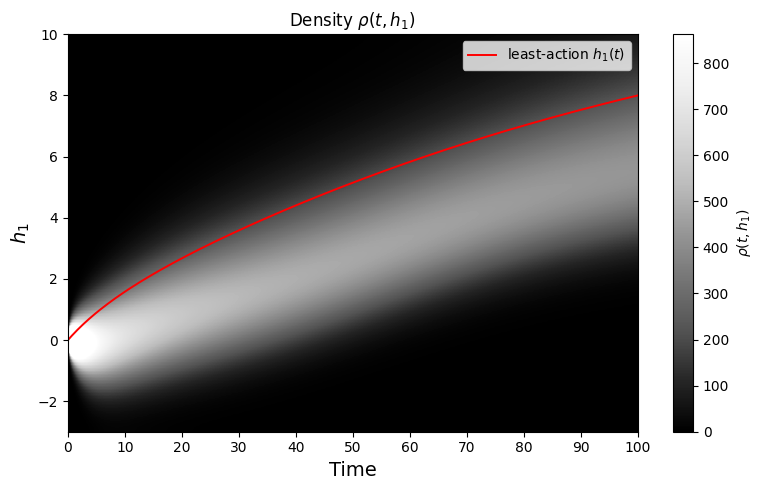

S_opt = -8.235413e-01   S_lin = -1.946231e-01   ΔS = 6.289183e-01

Running FP simulation for T=140 seconds
Optimal trajectory: (300,) with shape (2, 300)


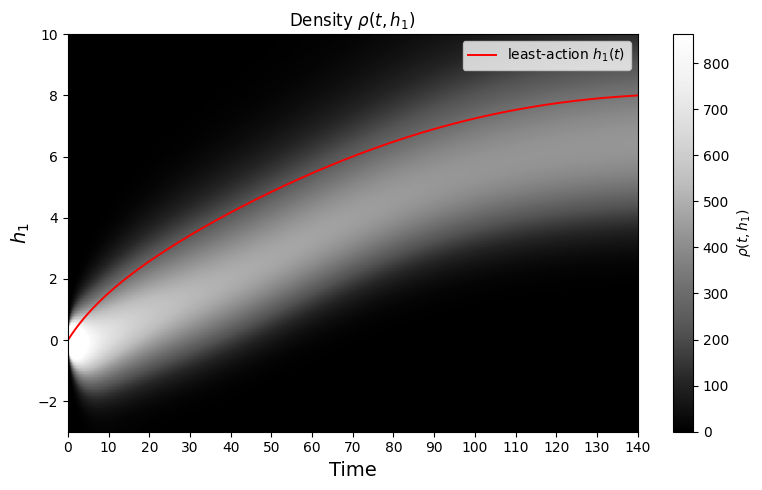

S_opt = -1.905386e+00   S_lin = 4.867140e-01   ΔS = 2.392100e+00
Saved sol.y[0] to trajectory_h.csv


In [7]:
import numpy as np
import copy

for T in [30, 100, 140]:
    print(f"\nRunning FP simulation for T={T} seconds")
    fp_ctx = run_fp(
        S_mat=np.array([[1.0]]),  # 2D shape space: h₁ and h₂
        get_C=lambda t, v: 300.0,
        T=T,
        verbose=False
    )
    fp_ctx_safe = copy.deepcopy(fp_ctx)
    sol = solve_optimal_trajectory([8], fp_ctx_safe)
    print(f"Optimal trajectory: {sol.x.shape} with shape {sol.y.shape}")
    plot_fp_density_time_dim(fp_ctx, sol=sol, disp_step=10, cmap="Greys_r")
    S, _ = compute_least_action(sol, fp_ctx, verbose=True)

    if T == 140:
        np.savetxt("trajectory_h_140.csv", sol.y[0], delimiter=",")
        print("Saved sol.y[0] to trajectory_h.csv")




# Same with pytorch

In [18]:
import numpy as np
import copy
import torch
import torch

def compute_least_action_torch(
    sol,
    fp_ctx,
    C_param,                         # torch scalar or (n_times,)
    *,
    # --- S controls ---
    S_mat_param=None,                # static S path (unused when S1_bins provided)
    S_row0_const=None,               # fixed scalar s0 (for N_h=2, n_A=1)
    S1_bins=None,                    # <-- (n_bins,) learnable bin params for s1
    bin_idx=None,                    # <-- (n_times,) long tensor mapping time -> bin
    # ---
    baseline=True, verbose=False, rtol=1e-8, atol=1e-10
):
    """
    Differentiable action with time-*binned* S on row 2 (N_h=2, n_A=1).
    If S1_bins & bin_idx are provided, we use per-time s1_k = S1_bins[bin_idx[k]].
    Gradients flow into S1_bins (and C_param if it requires grad).
    """
    dtype  = torch.float64
    device = C_param.device

    # Unpack FP context
    times   = torch.as_tensor(fp_ctx["times"],   dtype=dtype, device=device)
    omegas0 = torch.as_tensor(fp_ctx["omegas"],  dtype=dtype, device=device)   # debug only
    Phi0    = torch.as_tensor(fp_ctx["Phi_bar"], dtype=dtype, device=device)   # debug only
    rho_np  = fp_ctx["rho_t"]
    axes_np = fp_ctx["axes"]

    n_times = times.numel()

    # Broadcast C(t)
    if C_param.ndim == 0:
        C_t = C_param.expand(n_times)
    elif C_param.numel() == n_times:
        C_t = C_param
    else:
        raise ValueError("C_param must be scalar or length n_times")

    # Decide S mode
    use_binned_S1 = (S1_bins is not None) and (bin_idx is not None)
    if use_binned_S1:
        # N_h=2, n_A=1 case
        S_row0_const = torch.tensor(float(S_row0_const), dtype=dtype, device=device)
        S1_bins = S1_bins.to(dtype=dtype, device=device)           # keep grad!
        bin_idx = bin_idx.to(device=device, dtype=torch.long)
        assert bin_idx.shape == (n_times,), "bin_idx must be (n_times,)"
        N_h, n_A = 2, 1
    else:
        # static S fallback
        if S_mat_param is None:
            S_mat = torch.as_tensor(fp_ctx["S_mat"], dtype=dtype, device=device)
            S_mat.requires_grad_(False)
        else:
            S_mat = S_mat_param.to(dtype=dtype, device=device)     # keep grad
        N_h, n_A = S_mat.shape

    # Grid tensors
    axes_t  = [torch.as_tensor(ax, dtype=dtype, device=device) for ax in axes_np]
    d_h     = axes_np[0][1] - axes_np[0][0]
    dH      = d_h ** N_h
    H_mesh  = torch.meshgrid(*axes_t, indexing="ij")
    H_stack = torch.stack(H_mesh, dim=0)                       # (N_h,*grid)

    # Weights
    w = torch.tensor([0.5, 0.5], dtype=dtype, device=device) if N_h == 2 else torch.ones(N_h, dtype=dtype, device=device)
    w_bcast = w.view(N_h, *([1] * (H_stack.ndim - 1)))

    rho_t = [torch.as_tensor(r, dtype=dtype, device=device) for r in rho_np]

    # 1) Φ̄ and Ω recomputation
    Phi_bar = torch.empty_like(times)
    Omega   = torch.empty_like(times)
    zero    = torch.zeros((), dtype=dtype, device=device)

    for k in range(n_times):
        Ck    = C_t[k]
        rho_k = rho_t[k]
        N_pop = rho_k.sum() * dH

        # Energies on grid at time k
        if use_binned_S1:
            s1k   = S1_bins[bin_idx[k]]
            S_k   = torch.stack([S_row0_const, s1k]).view(N_h, 1)          # (2,1)
            H_w   = H_stack * w_bcast
            E_k   = torch.tensordot(S_k.T, H_w, dims=([1],[0]))            # (1,*grid)
        else:
            S_w   = S_mat * w[:, None]
            E_k   = torch.tensordot(S_w.T, H_stack, dims=([1],[0]))        # (n_A,*grid)

        exp_E_k      = torch.exp(E_k / kBT)
        exp_Eshift_k = torch.exp((E_k - E_a) / kBT)

        Phi_grid_k           = exp_E_k.sum(dim=0)
        PAg_numer_grid_sum_k = exp_Eshift_k.sum(dim=0)

        Phi_bar_k  = (rho_k * Phi_grid_k).sum() * dH / N_pop
        Phi_bar[k] = Phi_bar_k

        numer_PAg = Ck * PAg_numer_grid_sum_k
        P_Ag_grid = numer_PAg / (1. + numer_PAg).clamp_min(1e-12)

        C_tot     = n_A * Ck
        denom_T   = (Phi_grid_k + Phi_bar_k / C_tot).clamp_min(1e-12)
        P_T_grid  = Phi_grid_k / denom_T

        log_sel = torch.log(P_Ag_grid.clamp_min(1e-12)) + torch.log(P_T_grid.clamp_min(1e-12))
        avg_log = (rho_k * log_sel).sum() * dH / N_pop

        Omega[k] = zero if (N_pop < N_max + 0.1) else torch.maximum(zero, lam + avg_log)

    # 2) Optimal trajectory
    t_mesh = torch.as_tensor(sol.x,              dtype=dtype, device=device)
    h_opt  = torch.as_tensor(sol.y[:N_h].T,      dtype=dtype, device=device)
    v_opt  = torch.as_tensor(sol.y[N_h:2*N_h].T, dtype=dtype, device=device)

    v_pref = torch.full((N_h,), f_aa * mu_M, dtype=dtype, device=device)

    def idx_time(t):
        return torch.argmin(torch.abs(times - t))

    # 3) Γ
    def Gamma(t, h):
        k       = idx_time(t)
        omega_k = Omega[k]
        Phi_b   = Phi_bar[k]
        Ck      = C_t[k]

        if use_binned_S1:
            s1k = S1_bins[bin_idx[k]]
            # E = sum_i h_i * s_i(t_k) * w_i ; here n_A=1
            E_v = (w[0]*S_row0_const*h[0] + w[1]*s1k*h[1]).unsqueeze(0)     # (1,)
        else:
            E_v = torch.mv((S_mat * w[:, None]).T, h)                        # (n_A,)

        P_Ag = (Ck * torch.exp((E_v - E_a) / kBT)).sum()
        P_Ag = P_Ag / (1. + P_Ag).clamp_min(1e-12)

        Phi  = torch.exp(E_v / kBT).sum()
        P_T  = Phi / (Phi + Phi_b / (n_A * Ck)).clamp_min(1e-12)

        return lam + torch.log(P_Ag.clamp_min(1e-12)) + torch.log(P_T.clamp_min(1e-12)) - omega_k

    # 4) Action
    def S_of(h, v):
        g_vals = torch.stack([Gamma(ti, hi) for ti, hi in zip(t_mesh, h)])
        kin    = ((v - v_pref).pow(2).sum(dim=1)) / (2. * D)
        return -torch.trapz(g_vals - kin, t_mesh)

    S_opt = S_of(h_opt, v_opt)

    if not baseline:
        return S_opt

    slope  = h_opt[-1] / (t_mesh[-1] - t_mesh[0])
    h_lin  = (t_mesh[:, None] - t_mesh[0]) * slope
    v_lin  = slope.repeat(t_mesh.numel(), 1)
    S_lin  = S_of(h_lin, v_lin)
    return S_opt, S_lin

def optimise_S1_binned(
    hf, S_mat_init=None, *,
    C0=5.0, n_bins=10, lr=0.10, n_steps=50, tol=1e-5, T=60.0, verbose=True
):
    """
    N_h=2, n_A=1. Fix C(t)=C0. Freeze s0=S[0,0].
    Learn n_bins shared values for s1; each FP snapshot t_k uses s1_bins[bin_idx[k]].
    Returns: (hist_bins, hist_action), (S0_fixed, S1_bins_torch)
    """
    if S_mat_init is None:
        S_mat_init = np.array([[1.0], [1.0]], dtype=np.float64)
    S_mat_init = np.asarray(S_mat_init, dtype=np.float64)
    assert S_mat_init.shape == (2,1), "Expected S_mat_init shape (2,1)"

    s0_fixed = float(S_mat_init[0,0])
    s1_init  = float(S_mat_init[1,0])

    # Probe once to get time grid
    probe   = run_fp(S_mat_init, lambda t, v: C0, T=T, verbose=False)
    times   = np.asarray(probe["times"])
    n_times = times.size
    t0, tf  = float(times[0]), float(times[-1])

    # Uniform binning over [t0, tf]
    bin_width = (tf - t0) / n_bins if n_bins > 0 else (tf - t0)
    bin_idx_np = np.clip(np.floor((times - t0) / bin_width).astype(int), 0, n_bins-1)
    bin_idx = torch.tensor(bin_idx_np, dtype=torch.long)

    # Learnable s1 per bin
    S1_bins = torch.full((n_bins,), s1_init, dtype=torch.float64, requires_grad=True)

    hist_bins, hist_action = [], []
    C_param = torch.tensor(float(C0), dtype=torch.float64, requires_grad=False)

    for it in range(n_steps):
        if verbose:
            print(f"\n▶ iteration {it+1:02d}/{n_steps}")

        # Effective s1 for FP snapshots: mean over timepoints (weighted by time counts)
        s1_per_time = S1_bins[bin_idx].detach()
        s1_eff = float(s1_per_time.mean().cpu().item())
        S_eff  = np.array([[s0_fixed], [s1_eff]], dtype=np.float64)

        # Refresh FP ctx with detached S
        fp_ctx = run_fp(S_eff, lambda t, v: C0, T=T, verbose=False)
        sol    = solve_optimal_trajectory(hf, copy.deepcopy(fp_ctx), mesh=100, plot=False)

        # Differentiable action wrt S1_bins
        S_opt, S_lin = compute_least_action_torch(
            sol, fp_ctx, C_param=C_param,
            S_row0_const=s0_fixed,
            S1_bins=S1_bins,
            bin_idx=bin_idx,
            baseline=True, verbose=False
        )

        # Gradient for all bins
        grad = torch.autograd.grad(S_opt, S1_bins, retain_graph=False, create_graph=False)[0]
        gmax = grad.abs().max().item()

        if verbose:
            print(f"   S = {S_opt.item():.6e}    S_lin = {S_lin.item():.6e}    ‖∇S‖_∞ = {gmax:.2e}")
            print(f"   bins: {S1_bins.detach().cpu().numpy()}")

        hist_bins.append(S1_bins.detach().cpu().numpy().copy())
        hist_action.append(S_opt.item())

        if gmax < tol:
            if verbose:
                print("   ✅ gradient below tolerance – stopping.")
            break

        with torch.no_grad():
            S1_bins -= lr * grad
            S1_bins.clamp_(0.0, 1.0)   # in-place clamp, keeps requires_grad=True
    # Return fixed s0 and the learned per-bin s1’s
    return (np.array(hist_bins), np.array(hist_action)), (torch.tensor(s0_fixed, dtype=torch.float64), S1_bins)
# Targets for each coordinate
hf = np.array([9.0, 0.0], dtype=np.float64)
S_mat_init = np.array([[1.0], [1.0]], dtype=np.float64)

(hist_bins, hist_action), (s0_fixed, S1_bins) = optimise_S1_binned(
    hf, S_mat_init=S_mat_init, C0=100.0, n_bins=20, lr=0.20, n_steps=20, tol=1e-5, T=30.0, verbose=True
)

print("s0 (fixed):", s0_fixed.item())
print("s1 per bin:", S1_bins.detach().cpu().numpy())



▶ iteration 01/20
   S = 8.163942e+00    S_lin = 8.387638e+00    ‖∇S‖_∞ = 5.39e-02
   bins: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

▶ iteration 02/20
   S = 8.152753e+00    S_lin = 8.375888e+00    ‖∇S‖_∞ = 5.40e-02
   bins: [1.         1.         1.         1.         1.         1.
 0.99761667 0.99574245 0.99432437 0.99326497 0.99250408 0.99198709
 0.99168217 0.99156087 0.99160456 0.99179618 0.99211945 0.99255836
 0.99309368 0.9943098 ]

▶ iteration 03/20
   S = 8.141527e+00    S_lin = 8.364105e+00    ‖∇S‖_∞ = 5.40e-02
   bins: [1.         1.         1.         1.         1.         1.
 0.99532299 0.99154467 0.98868018 0.98653537 0.98499054 0.9839366
 0.98331023 0.98305461 0.98313274 0.98351066 0.98415589 0.98503639
 0.98611355 0.98857942]

▶ iteration 04/20
   S = 8.130266e+00    S_lin = 8.352292e+00    ‖∇S‖_∞ = 5.41e-02
   bins: [1.         1.         1.         1.         1.         1.
 0.99312181 0.98740919 0.98306951 0.97981276 0.97746044 0.97584909
 0.9748

In [ ]:
S_mat = np.array([[1.]], dtype=float)   # two shape coords, 1 Ag
hf     = [8]  
c=10
def get_C(t, v):
        return c
fp_ctx = run_fp(
        S_mat=np.array([[1.0]]),  # 2D shape space: h₁ and h₂
        get_C=get_C,
        T=60,
        verbose=False
    )
fp_ctx["get_C"] = get_C

# --- 2. least‑action path to hf ----------------------------
sol = solve_optimal_trajectory(hf, fp_ctx, plot=False, mesh=100)


# C_param = torch.tensor(float(10), dtype=torch.float64, requires_grad=True)
# --- 1. fresh FP run with the *current* C -------------------
                                             # scalar float
# --- 3. action + gradient wrt C ----------------------------
init_C=c
times      = torch.tensor(fp_ctx["times"],  dtype=torch.float64)

n_times    = len(times)
C_param = torch.nn.Parameter(
        torch.full((n_times,), init_C, dtype=torch.float64)
    )

S_opt_np = compute_least_action(sol, fp_ctx, baseline=True, verbose=True)
print('np',S_opt_np)
S_opt, S_lin = compute_least_action_torch(
    sol, fp_ctx, C_param=C_param, baseline=True, verbose=True)
print('torch',S_opt)
print('torch lin',S_lin)


S_opt = -2.449873e+00   S_lin = 5.621684e+01   ΔS = 5.866671e+01
np (-2.4498727061072136, 56.21684007810771)
max rel error Φ̄: 8.336e-16
max rel error Ω : 2.762e+11
max Φ̄ diff at index 4903: 8.728e+03 vs 8.728e+03
max Ω  diff at index 2606: 2.762e-01 vs 0.000e+00
torch tensor(-2.2811, dtype=torch.float64, grad_fn=<NegBackward0>)
torch lin tensor(56.3856, dtype=torch.float64, grad_fn=<NegBackward0>)


In [ ]:
S_opt_np = compute_least_action(sol, fp_ctx, baseline=False, verbose=True)
print('np',S_opt_np)

S_opt = -2.449873e+00
np -2.4498727061072136


In [ ]:
S_opt, dS_dC = compute_least_action_torch(
    sol, fp_ctx, C_param=C_param, baseline=True, verbose=True)
print('torch',S_opt)

max rel error Φ̄: 8.336e-16
max rel error Ω : 2.762e+11
max Φ̄ diff at index 4903: 8.728e+03 vs 8.728e+03
max Ω  diff at index 2606: 2.762e-01 vs 0.000e+00
torch tensor(-2.2811, dtype=torch.float64, grad_fn=<NegBackward0>)


In [ ]:
stop()

# Different concentrations

In [ ]:
import numpy as np, torch, copy, math, os, warnings
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
warnings.filterwarnings("ignore", category=UserWarning,
                        message="KMP_DUPLICATE_LIB_OK")

# ---------------------------------------------------------------------
# optimise_multiC_20  – 20 log-concentration parameters over whole span
# ---------------------------------------------------------------------
def optimise_multiC_20(
    hf, S_mat, *,
    C0        = 5.0,      # initial concentration in every bin
    lr        = 0.20,     # learning-rate in log-space
    n_steps   = 25,
    tol       = 1e-4,
    T         = 60.0,     # FP horizon
    verbose   = True, 
    n=20 #nb of bins
):
    """
    Learns 20 parameters L_bins = log C_bins such that
        C(t) = exp(L_bins[bin_of(t)]).
    The 20 bins partition the total FP time span uniformly.
    """
    # ------------------------------------------------------------------
    # ① Build once the FP time grid & snapshot → bin mapping
    # ------------------------------------------------------------------
    fp_probe = run_fp(S_mat, lambda t, v: C0, T=T, verbose=False)
    times_np = np.asarray(fp_probe["times"])

    t0, tf   = times_np[0], times_np[-1]
    bin_width = (tf - t0) / n                       # Δt per bin

    bin_idx = torch.tensor(
        np.clip(np.floor((times_np - t0) / bin_width).astype(int), 0, n-1),
        dtype=torch.long
    )

    # 20 learnable *log*-concentrations
    L_bins = torch.full((n,),
                        math.log(C0),
                        dtype=torch.float64,
                        requires_grad=True)

    hist_C, hist_S = [], []                            # diagnostics

    for it in range(n_steps):
        if verbose:
            print(f"\n▶ iteration {it+1:02d}/{n_steps}")

        # --------------------------------------------------------------
        # ② Build per-snapshot concentration tensor (keeps grad)
        # --------------------------------------------------------------
        C_bins  = torch.exp(L_bins)          # (20,) positive, grad-aware
        C_param = C_bins[bin_idx]            # (n_times,)

        # --------------------------------------------------------------
        # ③ Run FP with detached numbers
        # --------------------------------------------------------------
        C_det = C_bins.detach().cpu().numpy()

        def get_C_piece(t, v, C_arr=C_det, t0=t0, bw=bin_width):
            idx = int((t - t0) // bw)
            if idx > n-1:
                idx = n-1
            return float(C_arr[idx])

        # Differentiable lookup
        def get_C_granular(t, v, C_arr=C_param, t0=t0, bw=bin_width):
            idx = int((t - t0) // bw)
            if idx > n-1:
                idx = n-1
            return C_arr[idx]                # Tensor → keeps grad

        fp_ctx = run_fp(S_mat, get_C_piece, T=T, verbose=False)
        fp_ctx["get_C"] = get_C_granular

        # --------------------------------------------------------------
        # ④ Optimal trajectory on same mesh
        # --------------------------------------------------------------
        sol = solve_optimal_trajectory(
            hf, copy.deepcopy(fp_ctx), mesh=200, plot=False
        )

        # --------------------------------------------------------------
        # ⑤ Action & gradient wrt L_bins
        # --------------------------------------------------------------
        S_opt, S_lin = compute_least_action_torch(
            sol, fp_ctx, C_param=C_param,
            baseline=True,     # <- now the function returns both values
            verbose=False
        )


        if L_bins.grad is not None:
            L_bins.grad.zero_()
        S_opt.backward()

        grad_L = L_bins.grad.detach().clone()      # (20,)

        # ------------------------------------------------ diagnostics --
        gmax = grad_L.abs().max().item()
        if verbose:
            print(f"   S = {S_opt.item():.6e}    ‖∇S‖_∞ = {gmax:.2e}")
            print("   C_bins :", C_bins.detach().cpu().numpy())
            print("   log(C) :", L_bins.detach().cpu().numpy())
            print("   grad log:", grad_L.cpu().numpy())

        hist_C.append(C_bins.detach().cpu().numpy().copy())
        hist_S.append(S_opt.item())

        if gmax < tol:
            if verbose:
                print("   ✅ gradient below tolerance – stopping.")
            break

        # --------------------------------------------------------------
        # ⑥ Gradient step in log-space
        # --------------------------------------------------------------
        with torch.no_grad():
            L_bins -= lr * grad_L
            L_bins.clamp_(min=-20.0)   # exp(-20) ≈ 2e-9 → keeps >0

        L_bins.grad = None             # clear for next loop

    return (np.array(hist_C), np.array(hist_S)), torch.exp(L_bins)


In [ ]:
S_mat = np.array([[1.]], dtype=float)   # two h‑coords, one antigen
hf    = [8]
n=10
T=30
(history, C_final) = optimise_multiC_20(
    hf, S_mat,
    C0=20., lr=0.2, n_steps=20, tol=1e-4, verbose=True, T=T, n=n
)

print("\nOptimised 20‑bin C values:")
print(np.round(C_final.detach().cpu().numpy(), 3))



▶ iteration 01/20
   S = 9.706122e-01    ‖∇S‖_∞ = 1.26e+00
   C_bins : [20. 20. 20. 20. 20. 20. 20. 20. 20. 20.]
   log(C) : [2.99573227 2.99573227 2.99573227 2.99573227 2.99573227 2.99573227
 2.99573227 2.99573227 2.99573227 2.99573227]
   grad log: [-1.26062218 -0.53231137 -0.24914532 -0.13691156  0.08850954  0.58948997
  0.55035973  0.52719815  0.51290731  0.48895197]

▶ iteration 02/20
   S = 8.605106e-01    ‖∇S‖_∞ = 1.11e+00
   C_bins : [25.7351229  22.24671924 21.02182824 20.55521306 19.649077   17.7757342
 17.91539372 17.99857599 18.05009253 18.13677925]
   log(C) : [3.24785671 3.10219455 3.04556134 3.02311459 2.97803037 2.87783428
 2.88566033 2.89029264 2.89315081 2.89794188]
   grad log: [-1.11001656 -0.49046772 -0.24441115 -0.13476104  0.51305911  0.64110654
  0.58248108  0.55122653  0.53281396  0.50470772]

▶ iteration 03/20
   S = 6.845973e-01    ‖∇S‖_∞ = 9.71e-01
   C_bins : [32.1322443  24.53959884 22.07495192 21.11675482 17.73284453 15.63657891
 15.94529995 16.11978399 

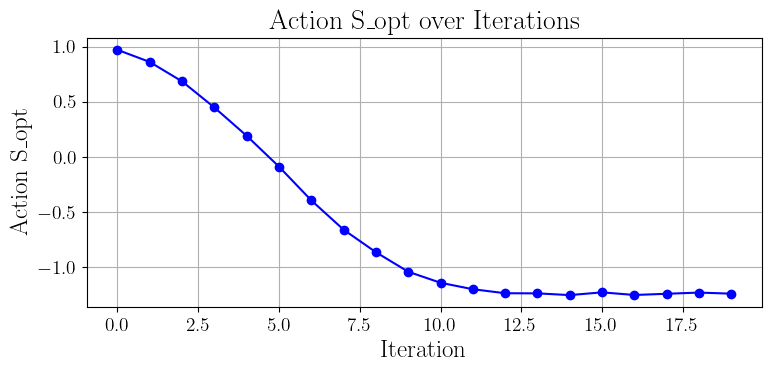

In [ ]:
history[1]#plot
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(history[1], marker='o', linestyle='-', color='blue')
plt.title("Action S_opt over Iterations")
plt.xlabel("Iteration")
plt.ylabel("Action S_opt")
plt.grid(True)
plt.tight_layout()
plt.show()



    1  t=  0.01  N=  2000.0  Ω=  0.000  ⟨Γ⟩=   0.071  ⟨h_1⟩= -0.00
    2  t=  0.02  N=  2001.4  Ω=  0.071  ⟨Γ⟩=  -0.001  ⟨h_1⟩= -0.00
    3  t=  0.03  N=  2001.4  Ω=  0.071  ⟨Γ⟩=  -0.001  ⟨h_1⟩= -0.00
    4  t=  0.04  N=  2001.4  Ω=  0.070  ⟨Γ⟩=  -0.001  ⟨h_1⟩= -0.00
    5  t=  0.05  N=  2001.4  Ω=  0.070  ⟨Γ⟩=  -0.001  ⟨h_1⟩= -0.00
    6  t=  0.06  N=  2001.4  Ω=  0.069  ⟨Γ⟩=  -0.001  ⟨h_1⟩= -0.00
    7  t=  0.07  N=  2001.4  Ω=  0.069  ⟨Γ⟩=  -0.001  ⟨h_1⟩= -0.00
    8  t=  0.08  N=  2001.4  Ω=  0.068  ⟨Γ⟩=  -0.001  ⟨h_1⟩= -0.01
    9  t=  0.09  N=  2001.4  Ω=  0.067  ⟨Γ⟩=  -0.001  ⟨h_1⟩= -0.01
   10  t=  0.10  N=  2001.4  Ω=  0.067  ⟨Γ⟩=  -0.000  ⟨h_1⟩= -0.01
   11  t=  0.11  N=  2001.4  Ω=  0.066  ⟨Γ⟩=  -0.000  ⟨h_1⟩= -0.01
   12  t=  0.12  N=  2001.4  Ω=  0.066  ⟨Γ⟩=  -0.000  ⟨h_1⟩= -0.01
   13  t=  0.13  N=  2001.4  Ω=  0.065  ⟨Γ⟩=  -0.000  ⟨h_1⟩= -0.01
   14  t=  0.14  N=  2001.4  Ω=  0.065  ⟨Γ⟩=  -0.000  ⟨h_1⟩= -0.01
   15  t=  0.15  N=  2001.4  Ω=  0.064  ⟨Γ⟩=  -0.000  ⟨h_1⟩= -

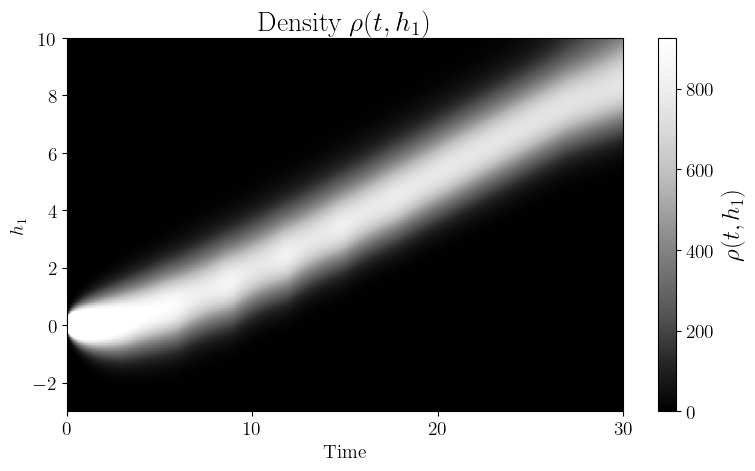

S_opt = -1.241207e+00   S_lin = 3.895190e+00   ΔS = 5.136397e+00


In [ ]:
# ------------------------------------------------------------------
# 1. Extract times from a dummy FP run to build bin mapping
# ------------------------------------------------------------------
fp_probe = run_fp(S_mat, lambda t, v: 5, T=T, verbose=False)
times_np = np.asarray(fp_probe["times"])
t0, tf   = times_np[0], times_np[-1]
n_bins   = len(C_final)
bin_width = (tf - t0) / n_bins

# ------------------------------------------------------------------
# 2. Define a concentration function using the optimized bins
# ------------------------------------------------------------------
C_final_np = C_final.detach().cpu().numpy()

def get_C_final(t, v):
    idx = int((t - t0) // bin_width)
    if idx >= n_bins:
        idx = n_bins - 1
    return float(C_final_np[idx])

# ------------------------------------------------------------------
# 3. Run the FP simulation with the optimized concentrations
# ------------------------------------------------------------------
fp_ctx_final = run_fp(S_mat, get_C_final, T=T, verbose=True)

fp_ctx_safe = copy.deepcopy(fp_ctx_final)
sol = solve_optimal_trajectory([8], fp_ctx_safe)
print(f"Optimal trajectory: {sol.x.shape} with shape {sol.y.shape}")
plot_fp_density_time_dim(fp_ctx_final, disp_step=10, cmap="Greys_r")
S,_=compute_least_action(sol, fp_ctx_final, verbose=True)
results={}
results['copt']=fp_ctx_safe


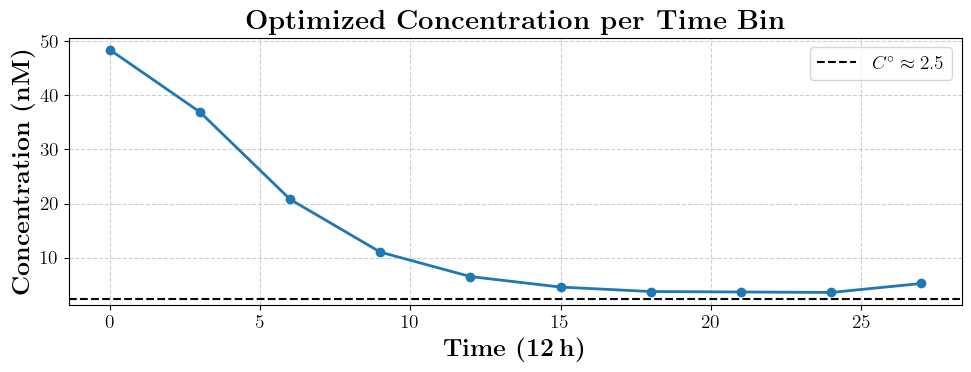

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# Convert tensor to NumPy array
C_np = C_final.detach().cpu().numpy()

# Value of C* (you must define this earlier in your code)

# Set large figure and font sizes
plt.figure(figsize=(10, 4))
plt.rcParams.update({
    "font.size": 16,
    "axes.labelsize": 18,
    "axes.titlesize": 20,
    "legend.fontsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "text.usetex": True,
    "font.family": "serif"
})

# Plot optimized C(t)
plt.plot(np.arange(0, len(C_np)) * T / n, C_np, marker='o', lw=2)

# Horizontal line at C*
plt.axhline(C_star, color='k', linestyle='--', linewidth=1.5, label=fr"$C^\circ \approx {C_star:.2g}$")

# Labels and formatting
plt.title(r"\textbf{Optimized Concentration per Time Bin}")
plt.xlabel(r"\textbf{Time (12\,h)}")
plt.ylabel(r"\textbf{Concentration (nM)}")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


    1  t=  0.01  N=  2000.0  Ω=  0.000  ⟨Γ⟩=  -0.613  ⟨h_1⟩= -0.00
    2  t=  0.02  N=  1987.7  Ω=  0.000  ⟨Γ⟩=  -0.614  ⟨h_1⟩= -0.00
    3  t=  0.03  N=  1975.4  Ω=  0.000  ⟨Γ⟩=  -0.615  ⟨h_1⟩= -0.00
    4  t=  0.04  N=  1963.2  Ω=  0.000  ⟨Γ⟩=  -0.616  ⟨h_1⟩= -0.00
    5  t=  0.05  N=  1951.0  Ω=  0.000  ⟨Γ⟩=  -0.616  ⟨h_1⟩= -0.00
    6  t=  0.06  N=  1939.0  Ω=  0.000  ⟨Γ⟩=  -0.617  ⟨h_1⟩= -0.00
    7  t=  0.07  N=  1926.9  Ω=  0.000  ⟨Γ⟩=  -0.618  ⟨h_1⟩= -0.00
    8  t=  0.08  N=  1915.0  Ω=  0.000  ⟨Γ⟩=  -0.619  ⟨h_1⟩= -0.00
    9  t=  0.09  N=  1903.1  Ω=  0.000  ⟨Γ⟩=  -0.619  ⟨h_1⟩= -0.01
   10  t=  0.10  N=  1891.2  Ω=  0.000  ⟨Γ⟩=  -0.620  ⟨h_1⟩= -0.01
   11  t=  0.11  N=  1879.4  Ω=  0.000  ⟨Γ⟩=  -0.621  ⟨h_1⟩= -0.01
   12  t=  0.12  N=  1867.7  Ω=  0.000  ⟨Γ⟩=  -0.621  ⟨h_1⟩= -0.01
   13  t=  0.13  N=  1856.0  Ω=  0.000  ⟨Γ⟩=  -0.622  ⟨h_1⟩= -0.01
   14  t=  0.14  N=  1844.4  Ω=  0.000  ⟨Γ⟩=  -0.623  ⟨h_1⟩= -0.01
   15  t=  0.15  N=  1832.9  Ω=  0.000  ⟨Γ⟩=  -0.623  ⟨h_1⟩= -

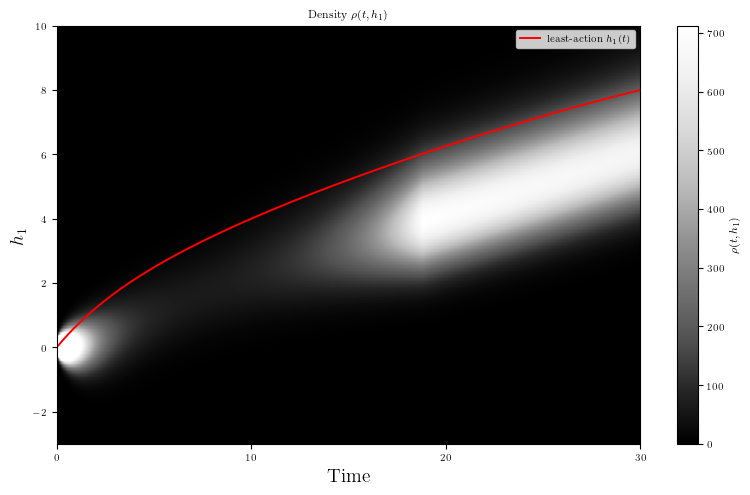

S_opt = 1.348912e-01   S_lin = 2.619241e+00   ΔS = 2.484350e+00


In [ ]:
def get_C(t, v):
    return C_final.mean().item()  # Use the mean of the optimized concentrations

# ------------------------------------------------------------------
# 3. Run the FP simulation with the optimized concentrations
# ------------------------------------------------------------------
fp_ctx_final = run_fp(S_mat, get_C, T=T, verbose=True)

fp_ctx_safe = copy.deepcopy(fp_ctx_final)
sol = solve_optimal_trajectory([8], fp_ctx_safe)
print(f"Optimal trajectory: {sol.x.shape} with shape {sol.y.shape}")
plot_fp_density_time_dim(fp_ctx_final, sol=sol, disp_step=10, cmap="Greys_r")
S,_=compute_least_action(sol, fp_ctx_final, verbose=True)
results['mean']=fp_ctx_safe

    1  t=  0.01  N=  2000.0  Ω=  0.000  ⟨Γ⟩=   0.478  ⟨h_1⟩= -0.00
    2  t=  0.02  N=  2009.5  Ω=  0.476  ⟨Γ⟩=  -0.000  ⟨h_1⟩= -0.00
    3  t=  0.03  N=  2009.5  Ω=  0.476  ⟨Γ⟩=  -0.000  ⟨h_1⟩= -0.00
    4  t=  0.04  N=  2009.5  Ω=  0.476  ⟨Γ⟩=  -0.000  ⟨h_1⟩= -0.00
    5  t=  0.05  N=  2009.5  Ω=  0.476  ⟨Γ⟩=  -0.000  ⟨h_1⟩= -0.00
    6  t=  0.06  N=  2009.5  Ω=  0.475  ⟨Γ⟩=  -0.000  ⟨h_1⟩= -0.00
    7  t=  0.07  N=  2009.5  Ω=  0.475  ⟨Γ⟩=  -0.000  ⟨h_1⟩= -0.00
    8  t=  0.08  N=  2009.5  Ω=  0.475  ⟨Γ⟩=  -0.000  ⟨h_1⟩= -0.01
    9  t=  0.09  N=  2009.5  Ω=  0.475  ⟨Γ⟩=  -0.000  ⟨h_1⟩= -0.01
   10  t=  0.10  N=  2009.5  Ω=  0.475  ⟨Γ⟩=  -0.000  ⟨h_1⟩= -0.01
   11  t=  0.11  N=  2009.5  Ω=  0.475  ⟨Γ⟩=  -0.000  ⟨h_1⟩= -0.01
   12  t=  0.12  N=  2009.5  Ω=  0.475  ⟨Γ⟩=  -0.000  ⟨h_1⟩= -0.01
   13  t=  0.13  N=  2009.5  Ω=  0.474  ⟨Γ⟩=  -0.000  ⟨h_1⟩= -0.01
   14  t=  0.14  N=  2009.5  Ω=  0.474  ⟨Γ⟩=  -0.000  ⟨h_1⟩= -0.01
   15  t=  0.15  N=  2009.5  Ω=  0.474  ⟨Γ⟩=  -0.000  ⟨h_1⟩= -

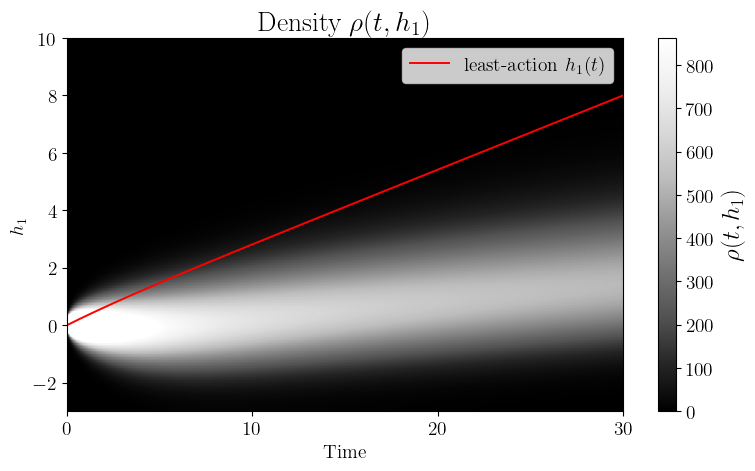

S_opt = 5.952495e+00   S_lin = 5.969967e+00   ΔS = 1.747164e-02


In [ ]:
def get_C(t, v):
    return 300.  # Use the mean of the optimized concentrations

# ------------------------------------------------------------------
# 3. Run the FP simulation with the optimized concentrations
# ------------------------------------------------------------------
fp_ctx_final = run_fp(S_mat, get_C, T=T, verbose=True)

fp_ctx_safe = copy.deepcopy(fp_ctx_final)
sol = solve_optimal_trajectory([8], fp_ctx_safe)
print(f"Optimal trajectory: {sol.x.shape} with shape {sol.y.shape}")
plot_fp_density_time_dim(fp_ctx_final, sol=sol, disp_step=10, cmap="Greys_r")
S,_=compute_least_action(sol, fp_ctx_final, verbose=True)
results['300']=fp_ctx_safe

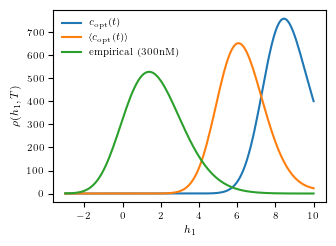

In [ ]:
import matplotlib.pyplot as plt

# Set PRL-compatible figure size and fonts
plt.figure(figsize=(3.4, 2.5))
plt.rcParams.update({
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "legend.fontsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "text.usetex": True,
    "font.family": "serif"
})

# Define label mapping
label_map = {
    "copt": r"$c_{\mathrm{opt}}(t)$",
    "mean": r"$\langle c_{\mathrm{opt}}(t) \rangle$",
    "300": r"empirical (300\,nM)"
}

# Plot
for key in ['copt', 'mean', '300']:
    if key not in results:
        print(key)
        continue
    res = results[key]
    plt.plot(res["axes"][0], res["rho_t"][-1], label=label_map[key], lw=1.5)

# Axis labels and formatting
plt.xlabel(r"$h_1$")
plt.ylabel(r"$\rho(h_1, T)$")
plt.legend(frameon=False, loc="upper left")
plt.tight_layout()
plt.show()
